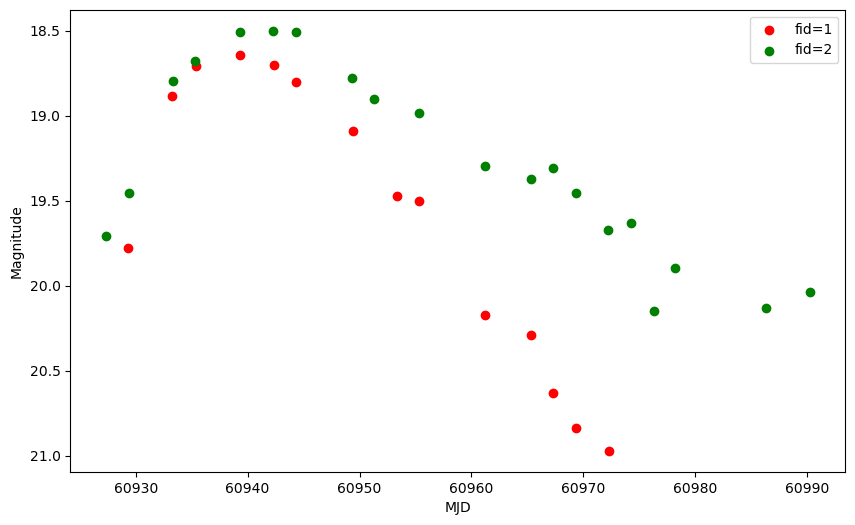

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data
df = pd.read_csv('ZTF25abqamzb_lightcurve.csv')

# columns
x = df['mjd']
y = df['magpsf']

# filter masks
fid1 = df['fid'] == 1
fid2 = df['fid'] == 2

# create figure and axes
fig, ax = plt.subplots(figsize=(10,6))

# scatter data
ax.scatter(x[fid1], y[fid1], color='red', label='fid=1')
ax.scatter(x[fid2], y[fid2], color='green', label='fid=2')



# formatting
ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")
ax.invert_yaxis()
ax.legend()

plt.show()

In [4]:
# split bands
g_band = df[df['fid'] == 1]
r_band = df[df['fid'] == 2]

# maximum magnitude (faintest point)
max_mag_g = g_band['magpsf'].max()
max_mag_r = r_band['magpsf'].max()

# magnitude -> flux conversion (Jy)
flux_g = 3631 * 10**(-0.4 * max_mag_g)
flux_r = 3631 * 10**(-0.4 * max_mag_r)

print("g-band:")
print("Max magnitude:", max_mag_g)
print("Flux (Jy):", flux_g)

print("\nr-band:")
print("Max magnitude:", max_mag_r)
print("Flux (Jy):", flux_r)


g-band:
Max magnitude: 20.9718
Flux (Jy): 1.4835638724806765e-05

r-band:
Max magnitude: 20.147589
Flux (Jy): 3.169499217685585e-05


In [5]:
1.4835638724806765e-05*100


0.0014835638724806765

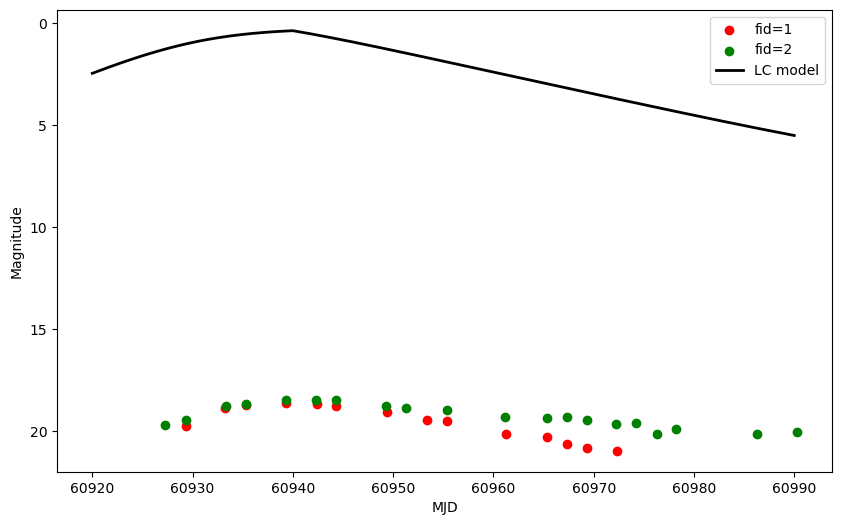

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data
df = pd.read_csv('ZTF25abqamzb_lightcurve.csv')

# columns
x = df['mjd']
y = df['magpsf']

# filter masks
fid1 = df['fid'] == 1
fid2 = df['fid'] == 2

# create figure and axes
fig, ax = plt.subplots(figsize=(10,6))

# scatter data
ax.scatter(x[fid1], y[fid1], color='red', label='fid=1')
ax.scatter(x[fid2], y[fid2], color='green', label='fid=2')


# ----- light curve model -----

def sn_lightcurve(t, A, beta, t0, trise, tfall, gamma, c):

    t1 = t0 + gamma
    F = np.zeros_like(t)

    mask1 = t < t1
    F[mask1] = (A + beta*(t[mask1]-t0)) / (1 + np.exp(-(t[mask1]-t0)/trise))

    mask2 = t >= t1
    F[mask2] = ((A + beta*(t1-t0)) * np.exp(-(t[mask2]-t1)/tfall)) / \
               (1 + np.exp(-(t[mask2]-t0)/trise))

    return F + c



# simple flux -> magnitude conversion
def fluxjy2mag(f):
    return -2.5 * np.log10(f / 3631)



# parameters
params = dict(
    A = 3000,
    beta = -10,
    t0 = 60930,
    trise = 5,
    tfall = 10,
    gamma = 10,
    c = 3
)


# model timeline
t_model = np.linspace(60920, 60990, 500)

flux_model = sn_lightcurve(t_model, **params)

# plot model
ax.plot(
    t_model,
    fluxjy2mag(flux_model),
    color='black',
    lw=2,
    label='LC model'
)

# formatting
ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")
ax.invert_yaxis()
ax.legend()

plt.show()

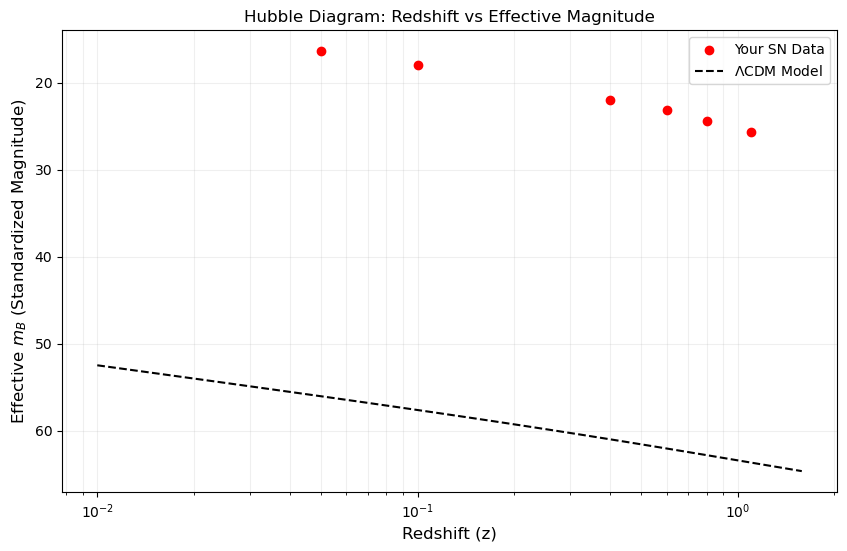

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import sncosmo

# 1. Setup your Cosmology (for the trendline)
# Modern values: H0 ~ 70, Omega_M ~ 0.3
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# 2. Example Data Setup (Replace these with your actual data)
# redshift (z), observed magnitude (m_obs), stretch (s), K-correction (K), Extinction (A)
z = np.array([0.05, 0.1, 0.4, 0.6, 0.8, 1.1])
m_obs = np.array([16.5, 18.2, 22.1, 23.4, 24.5, 25.8])
stretch = np.array([1.02, 0.98, 1.05, 0.95, 1.0, 1.01]) # 's' factor
alpha = 1.3  # Standard nuisance parameter for stretch correction
K_corr = 0.1 # K-correction
A_ext = 0.05 # Galactic Extinction

# 3. Calculate Effective Magnitude (as per your formula)
# mB_eff = m_obs + alpha*(s - 1) - K - A
mB_eff = m_obs + alpha * (stretch - 1) - K_corr - A_ext

# 4. Generate the Theoretical Hubble Line
z_range = np.logspace(-2, 0.2, 100) # redshift from 0.01 to ~1.5
# Distance modulus: mu = 5 * log10(dL / 10pc)
dist_mod = cosmo.distmod(z_range).value 

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(z, mB_eff, color='red', label='Your SN Data', zorder=5)
plt.plot(z_range, dist_mod + 19.3, color='black', label='$\Lambda$CDM Model', linestyle='--') # 19.3 is approx MB

plt.xscale('log') # Standard practice for Hubble diagrams
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('Effective $m_B$ (Standardized Magnitude)', fontsize=12)
plt.title('Hubble Diagram: Redshift vs Effective Magnitude')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.gca().invert_yaxis() # Magnitude scale is inverted (lower = brighter)
plt.show()

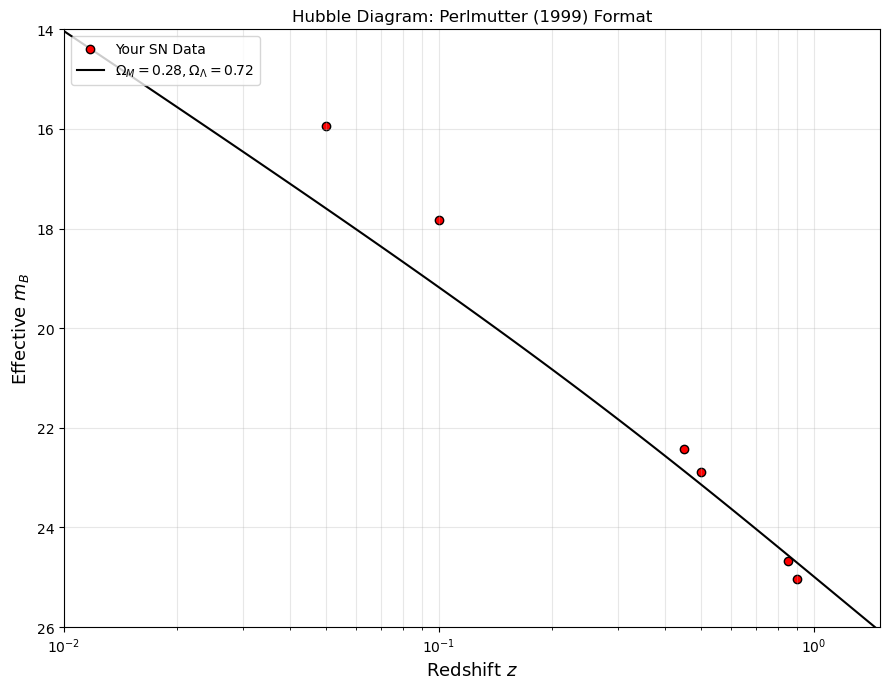

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# 1. Setup Cosmology for theoretical lines
# Omega_M = 0.28, Omega_L = 0.72 is a close match to the 1999 "Best Fit"
cosmo = FlatLambdaCDM(H0=65, Om0=0.28) 

# 2. Your Data (Replace with your actual arrays)
z = np.array([0.05, 0.1, 0.45, 0.5, 0.85, 0.9]) # Redshift
mR = np.array([16.1, 18.0, 22.5, 23.1, 24.8, 25.2]) # Observed R-band mag
s = np.array([1.0, 0.98, 1.05, 0.95, 1.02, 0.99])  # Stretch factor
KBR = 0.1  # K-correction (simplified constant for this example)
AR = 0.05  # Galactic Extinction
alpha = 1.3 # Stretch-luminosity parameter

# 3. Calculate Effective mB using your specific formula
# mB_eff = mR + alpha(s - 1) - KBR - AR
mB_eff = mR + alpha * (s - 1) - KBR - AR

# 4. Theoretical Model Lines
z_line = np.logspace(-2, 0.2, 100)
# We add -19.3 (Absolute Magnitude M_B) to convert Distance Modulus to mB_eff
theory_mB = cosmo.distmod(z_line).value + (-19.3) 

# 5. Plotting to match Perlmutter et al. 1999
plt.figure(figsize=(9, 7))

# Plot Data
plt.scatter(z, mB_eff, color='red', label='Your SN Data', marker='o', edgecolors='black')

# Plot Theory
plt.plot(z_line, theory_mB, color='black', label='$\Omega_M=0.28, \Omega_\Lambda=0.72$')

# Formatting to match the paper
plt.xscale('log')
plt.xlim(0.01, 1.5)
plt.ylim(26, 14) # Inverted Y-axis from 26 down to 14
plt.xlabel('Redshift $z$', fontsize=13)
plt.ylabel('Effective $m_B$', fontsize=13)
plt.title('Hubble Diagram: Perlmutter (1999) Format')
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [9]:
!pip install numpy matplotlib astropy pandas dustmaps

In [10]:
from dustmaps.config import config
config['data_dir'] = './dustmaps_data'  # directory where the maps will be stored

from dustmaps import sfd
sfd.fetch()

Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.


In [11]:
pip install numpy pandas matplotlib astropy sncosmo dustmaps


Note: you may need to restart the kernel to use updated packages.


In [12]:
from dustmaps import sfond
sfond.fetch()

ImportError: cannot import name 'sfond' from 'dustmaps' (/opt/anaconda3/lib/python3.13/site-packages/dustmaps/__init__.py)

In [13]:
from astropy.table import Table
from astropy.io import ascii
from astropy.table import QTable
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
%config InlineBackend.figure_format='retina'
%matplotlib notebook
# %matplotlib inline

import math
import seaborn as sns
from scipy import stats



In [14]:
df = pd.read_csv('df_snia_with_tns_match_plus_dm15.csv')
df

,oid,mjd,fid,magpsf,sigmapsf,ra,dec,tid,tns_match,tns_sep_arcsec,...,tns_name_prefix,tns_type,tns_redshift,tns_full_name,band,status,dm15,e_dm15,Tmax,e_Tmax
0,ZTF20acobvxk,59149.448125,1,19.810800,0.236357,37.673496,-14.569211,ztf,True,0.299260,...,SN,SN Ia,0.080,SN 2020ymv,g,ok,0.866332,0.048836,59163.747572,0.295674
1,ZTF20acobvxk,59151.272535,1,19.568500,0.277572,37.673642,-14.569045,ztf,True,0.578001,...,SN,SN Ia,0.080,SN 2020ymv,g,ok,0.866332,0.048836,59163.747572,0.295674
2,ZTF20acobvxk,59151.350405,2,19.385900,0.217224,37.673397,-14.569204,ztf,True,0.450946,...,SN,SN Ia,0.080,SN 2020ymv,r,ok,0.866332,0.048836,59163.747572,0.295674
3,ZTF20acobvxk,59152.264155,1,19.226200,0.222367,37.673513,-14.568956,ztf,True,0.621037,...,SN,SN Ia,0.080,SN 2020ymv,g,ok,0.866332,0.048836,59163.747572,0.295674
4,ZTF20acobvxk,59153.332118,2,18.783262,0.167610,37.673557,-14.569205,ztf,True,0.344176,...,SN,SN Ia,0.080,SN 2020ymv,r,ok,0.866332,0.048836,59163.747572,0.295674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50060,ZTF21abbybbx,59373.257627,1,20.000400,0.236171,185.592923,10.793056,ztf,True,0.246703,...,SN,SN Ia,0.094,SN 2021mwc,g,ok,1.480706,0.042299,59361.574712,0.368731
50061,ZTF21abbybbx,59375.256898,1,20.228900,0.291973,185.593000,10.792984,ztf,True,0.587012,...,SN,SN Ia,0.094,SN 2021mwc,g,ok,1.480706,0.042299,59361.574712,0.368731
50062,ZTF21abbybbx,59377.211505,2,19.883846,0.149404,185.592861,10.793059,ztf,True,0.026926,...,SN,SN Ia,0.094,SN 2021mwc,r,ok,1.480706,0.042299,59361.574712,0.368731
50063,ZTF21abbybbx,59379.207558,1,20.678500,0.321523,185.592838,10.793127,ztf,True,0.244923,...,SN,SN Ia,0.094,SN 2021mwc,g,ok,1.480706,0.042299,59361.574712,0.368731


In [15]:
!pip install numpy pandas matplotlib astropy sncosmo dustmaps

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sncosmo
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from dustmaps.config import config
from dustmaps import sfd
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# CONFIGURATION – CHANGE THESE TO MATCH YOUR DATA
# ------------------------------------------------------------
CSV_FILE = 'df_snia_with_tns_match_plus_dm15.csv'

# Column names in your CSV
COL_Z = 'tns_redshift'          # redshift column (maybe 'redshift' or 'z')
COL_MAG = 'magpsf'               # observed magnitude (g-band)
COL_MAGERR = 'sigmapsf'          # error on observed magnitude
COL_FID = 'fid'                  # filter ID (1=red, 2=green)
COL_DM15 = 'dm15'                 # Δm15 value
COL_DM15ERR = 'e_dm15'            # error on Δm15
COL_RA = 'ra'                     # RA in degrees
COL_DEC = 'dec'                   # Dec in degrees

# Filter mapping: which fid corresponds to g-band?
GREEN_FID = 2                      # assuming 2 = green / g-band

# Width-luminosity slope (you can later fit it)
ALPHA = 0.6

# Relation between stretch s and Δm15:  s = a + b * dm15
# (adjust these coefficients if you have a better calibration)
def dm15_to_stretch(dm15, a=1.24, b=-0.18):
    return a + b * dm15

# Observed band name in sncosmo (for K-correction)
# SDSS g-band is 'sdssg'. If you have a different g-band, change this.
OBS_BAND = 'sdssg'
# Rest-frame B band
REST_BAND = 'bessellb'

# Galactic extinction: R_g for your observed band (for SDSS g, ~3.2)
R_BAND = 3.2                       # A_band / E(B-V)

# Intrinsic dispersion of SNe Ia after stretch correction (mag)
INTRINSIC_DISP = 0.17

# Assumed uncertainty in K-correction (mag)
K_ERR = 0.02

# ------------------------------------------------------------
# 1. Load data and select g-band observations
# ------------------------------------------------------------
data = pd.read_csv(CSV_FILE)
print("Columns found:", data.columns.tolist())

# Keep only g-band (green filter) data
data_g = data[data[COL_FID] == GREEN_FID].copy()
if len(data_g) == 0:
    raise ValueError("No g-band data found (fid != {})".format(GREEN_FID))

# Drop rows with missing essential values
data_g.dropna(subset=[COL_Z, COL_MAG, COL_DM15, COL_RA, COL_DEC], inplace=True)

# ------------------------------------------------------------
# 2. Compute stretch factor s and its error
# ------------------------------------------------------------
def stretch_and_error(dm15, e_dm15, a=1.24, b=-0.18):
    s = a + b * dm15
    e_s = abs(b) * e_dm15
    return s, e_s

s_vals, e_s_vals = zip(*[stretch_and_error(row[COL_DM15], row[COL_DM15ERR])
                          for idx, row in data_g.iterrows()])
data_g['s'] = s_vals
data_g['e_s'] = e_s_vals

# ------------------------------------------------------------
# 3. Galactic extinction from RA, Dec using Schlegel maps
# ------------------------------------------------------------

config['data_dir'] = './dustmaps_data'
# sfd.fetch()   # uncomment on first run

sfd_query = sfd.SFDQuery()

def galactic_extinction(ra, dec, band_R=R_BAND):
    # Create SkyCoord object from RA, Dec (assumed degrees)
    coord = SkyCoord(ra, dec, unit='deg', frame='icrs')
    ebv = sfd_query(coord)          # E(B-V) from Schlegel map
    return band_R * ebv, 0.1 * band_R * ebv   # A_band and rough uncertainty (10%)

extinctions = [galactic_extinction(row[COL_RA], row[COL_DEC]) for idx, row in data_g.iterrows()]
data_g['A_gal'], data_g['e_A_gal'] = zip(*extinctions)

# ------------------------------------------------------------
# 4. K-correction using sncosmo – precompute grid for speed
# ------------------------------------------------------------
import numpy as np
from scipy.interpolate import interp1d

model = sncosmo.Model(source='hsiao')

obs_band = sncosmo.get_bandpass(OBS_BAND)
rest_band = sncosmo.get_bandpass(REST_BAND)

z_min = max(0.01, data_g[COL_Z].min() - 0.05)
z_max = data_g[COL_Z].max() + 0.05
z_grid = np.linspace(z_min, z_max, 100)

k_grid = []

for z in z_grid:
    try:
        k = sncosmo.kcorr(model, z, obs_band, rest_band)
    except Exception as e:
        print(f"Grid point z={z:.3f} failed: {e}")
        k = np.nan
    k_grid.append(k)

k_grid = np.array(k_grid)

valid = np.isfinite(k_grid)

if np.sum(valid) < 2:
    raise RuntimeError("K-correction grid failed — check bandpass names.")

z_grid = z_grid[valid]
k_grid = k_grid[valid]

k_interp = interp1d(
    z_grid,
    k_grid,
    kind='linear',
    bounds_error=False,
    fill_value="extrapolate"
)

k_vals = k_interp(data_g[COL_Z].values)

data_g['K'] = k_vals
data_g['e_K'] = K_ERR

# ------------------------------------------------------------
# 5. Compute effective B magnitude and its uncertainty
# ------------------------------------------------------------
data_g['mB_eff'] = data_g[COL_MAG] + ALPHA * (data_g['s'] - 1) - data_g['K'] - data_g['A_gal']

data_g['e_mB_eff'] = np.sqrt(
    data_g[COL_MAGERR]**2 +
    (ALPHA * data_g['e_s'])**2 +
    data_g['e_K']**2 +
    data_g['e_A_gal']**2 +
    INTRINSIC_DISP**2
)

# ------------------------------------------------------------
# 6. Plot mB_eff vs redshift
# ------------------------------------------------------------
plt.figure(figsize=(9, 7))
plt.errorbar(data_g[COL_Z], data_g['mB_eff'], yerr=data_g['e_mB_eff'],
             fmt='o', capsize=2, markersize=4, label='My SNe Ia (g-band)')

# Overlay theoretical curves for flat cosmologies
z_plot = np.linspace(0, data_g[COL_Z].max(), 100)
def mag_model(z, Om, H0=70, M0=-19.3):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    return M0 + cosmo.distmod(z).value

plt.plot(z_plot, mag_model(z_plot, 0.28), 'r-', label=r'$\Omega_m=0.28$, flat')
plt.plot(z_plot, mag_model(z_plot, 0.50), 'g--', label=r'$\Omega_m=0.50$, flat')
plt.plot(z_plot, mag_model(z_plot, 1.00), 'b:', label=r'$\Omega_m=1.00$, flat')

plt.xlabel('Redshift z')
plt.ylabel(r'$m_B^{\mathrm{eff}}$')
plt.legend()
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.title('Effective B magnitude vs redshift (g-band SNe Ia)')
plt.tight_layout()
plt.show()

# Save computed data to a new CSV
data_g[['tns_name', COL_Z, 'mB_eff', 'e_mB_eff']].to_csv('mB_eff_data.csv', index=False)

Columns found: ['oid', 'mjd', 'fid', 'magpsf', 'sigmapsf', 'ra', 'dec', 'tid', 'tns_match', 'tns_sep_arcsec', 'tns_name', 'tns_name_prefix', 'tns_type', 'tns_redshift', 'tns_full_name', 'band', 'status', 'dm15', 'e_dm15', 'Tmax', 'e_Tmax']
Grid point z=0.010 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.012 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.014 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.015 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.017 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.019 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.021 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.023 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.025 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.026 failed: module 'sncosmo' has no attribute 'kcorr'
Grid point z=0.028 failed: module 'sncosmo' has no attribute 'kcorr'
G

RuntimeError: K-correction grid failed — check bandpass names.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sncosmo
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from dustmaps.config import config
from dustmaps import sfd
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# CONFIGURATION – CHANGE THESE TO MATCH YOUR DATA
# ------------------------------------------------------------
CSV_FILE = 'df_snia_with_tns_match_plus_dm15.csv'

# Column names in your CSV
COL_Z = 'tns_redshift'          # redshift column (maybe 'redshift' or 'z')
COL_MAG = 'magpsf'               # observed magnitude (g-band)
COL_MAGERR = 'sigmapsf'          # error on observed magnitude
COL_FID = 'fid'                  # filter ID (1=red, 2=green)
COL_DM15 = 'dm15'                 # Δm15 value
COL_DM15ERR = 'e_dm15'            # error on Δm15
COL_RA = 'ra'                     # RA in degrees
COL_DEC = 'dec'                   # Dec in degrees

# Filter mapping: which fid corresponds to g-band?
GREEN_FID = 2                      # assuming 2 = green / g-band

# Width-luminosity slope (you can later fit it)
ALPHA = 0.6

# Relation between stretch s and Δm15:  s = a + b * dm15
# (adjust these coefficients if you have a better calibration)
def dm15_to_stretch(dm15, a=1.24, b=-0.18):
    return a + b * dm15

# Observed band name in sncosmo (for K-correction)
# SDSS g-band is 'sdssg'. If you have a different g-band, change this.
OBS_BAND = 'sdssg'
# Rest-frame B band
REST_BAND = 'bessellb'

# Galactic extinction: R_g for your observed band (for SDSS g, ~3.2)
R_BAND = 3.2                       # A_band / E(B-V)

# Intrinsic dispersion of SNe Ia after stretch correction (mag)
INTRINSIC_DISP = 0.17

# Assumed uncertainty in K-correction (mag)
K_ERR = 0.02

# ------------------------------------------------------------
# 1. Load data and select g-band observations
# ------------------------------------------------------------
data = pd.read_csv(CSV_FILE)
print("Columns found:", data.columns.tolist())

# Keep only g-band (green filter) data
data_g = data[data[COL_FID] == GREEN_FID].copy()
if len(data_g) == 0:
    raise ValueError("No g-band data found (fid != {})".format(GREEN_FID))

# Drop rows with missing essential values
data_g.dropna(subset=[COL_Z, COL_MAG, COL_DM15, COL_RA, COL_DEC], inplace=True)

# ------------------------------------------------------------
# 2. Compute stretch factor s and its error
# ------------------------------------------------------------
def stretch_and_error(dm15, e_dm15, a=1.24, b=-0.18):
    s = a + b * dm15
    e_s = abs(b) * e_dm15
    return s, e_s

s_vals, e_s_vals = zip(*[stretch_and_error(row[COL_DM15], row[COL_DM15ERR])
                          for idx, row in data_g.iterrows()])
data_g['s'] = s_vals
data_g['e_s'] = e_s_vals

# ------------------------------------------------------------
# 3. Galactic extinction from RA, Dec using Schlegel maps
# ------------------------------------------------------------

config['data_dir'] = './dustmaps_data'
# sfd.fetch()   # uncomment on first run

sfd_query = sfd.SFDQuery()

def galactic_extinction(ra, dec, band_R=R_BAND):
    # Create SkyCoord object from RA, Dec (assumed degrees)
    coord = SkyCoord(ra, dec, unit='deg', frame='icrs')
    ebv = sfd_query(coord)          # E(B-V) from Schlegel map
    return band_R * ebv, 0.1 * band_R * ebv   # A_band and rough uncertainty (10%)

extinctions = [galactic_extinction(row[COL_RA], row[COL_DEC]) for idx, row in data_g.iterrows()]
data_g['A_gal'], data_g['e_A_gal'] = zip(*extinctions)

# ------------------------------------------------------------
# 4. K-correction using sncosmo – precompute grid for speed
# ------------------------------------------------------------
model = sncosmo.Model(source='hsiao')

obs_band = sncosmo.get_bandpass(OBS_BAND)
rest_band = sncosmo.get_bandpass(REST_BAND)

def compute_kcorr(z):
    model.set(z=z)
    m_obs = model.bandmag(obs_band, 'ab', 0)
    m_rest = model.bandmag(rest_band, 'ab', 0)
    return m_obs - m_rest

data_g['K'] = data_g[COL_Z].apply(compute_kcorr)
data_g['e_K'] = K_ERR
# ------------------------------------------------------------
# 5. Compute effective B magnitude and its uncertainty
# ------------------------------------------------------------
data_g['mB_eff'] = data_g[COL_MAG] + ALPHA * (data_g['s'] - 1) - data_g['K'] - data_g['A_gal']

data_g['e_mB_eff'] = np.sqrt(
    data_g[COL_MAGERR]**2 +
    (ALPHA * data_g['e_s'])**2 +
    data_g['e_K']**2 +
    data_g['e_A_gal']**2 +
    INTRINSIC_DISP**2
)

# ------------------------------------------------------------
# 6. Plot mB_eff vs redshift
# ------------------------------------------------------------
plt.figure(figsize=(9, 7))
plt.errorbar(data_g[COL_Z], data_g['mB_eff'], yerr=data_g['e_mB_eff'],
             fmt='o', capsize=2, markersize=4, label='My SNe Ia (g-band)')

# Overlay theoretical curves for flat cosmologies
z_plot = np.linspace(0, data_g[COL_Z].max(), 100)
def mag_model(z, Om, H0=70, M0=-19.3):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    return M0 + cosmo.distmod(z).value

plt.plot(z_plot, mag_model(z_plot, 0.28), 'r-', label=r'$\Omega_m=0.28$, flat')
plt.plot(z_plot, mag_model(z_plot, 0.50), 'g--', label=r'$\Omega_m=0.50$, flat')
plt.plot(z_plot, mag_model(z_plot, 1.00), 'b:', label=r'$\Omega_m=1.00$, flat')

plt.xlabel('Redshift z')
plt.ylabel(r'$m_B^{\mathrm{eff}}$')
plt.legend()
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.title('Effective B magnitude vs redshift (g-band SNe Ia)')
plt.tight_layout()
plt.show()

# Save computed data to a new CSV
data_g[['tns_name', COL_Z, 'mB_eff', 'e_mB_eff']].to_csv('mB_eff_data.csv', index=False)

Columns found: ['oid', 'mjd', 'fid', 'magpsf', 'sigmapsf', 'ra', 'dec', 'tid', 'tns_match', 'tns_sep_arcsec', 'tns_name', 'tns_name_prefix', 'tns_type', 'tns_redshift', 'tns_full_name', 'band', 'status', 'dm15', 'e_dm15', 'Tmax', 'e_Tmax']


<IPython.core.display.Javascript object>

In [ ]:
data_plot = pd.read_csv("mB_eff_data.csv")
print(data_plot.head())
print(len(data_plot))

NameError: name 'pd' is not defined

In [16]:
%matplotlib inline

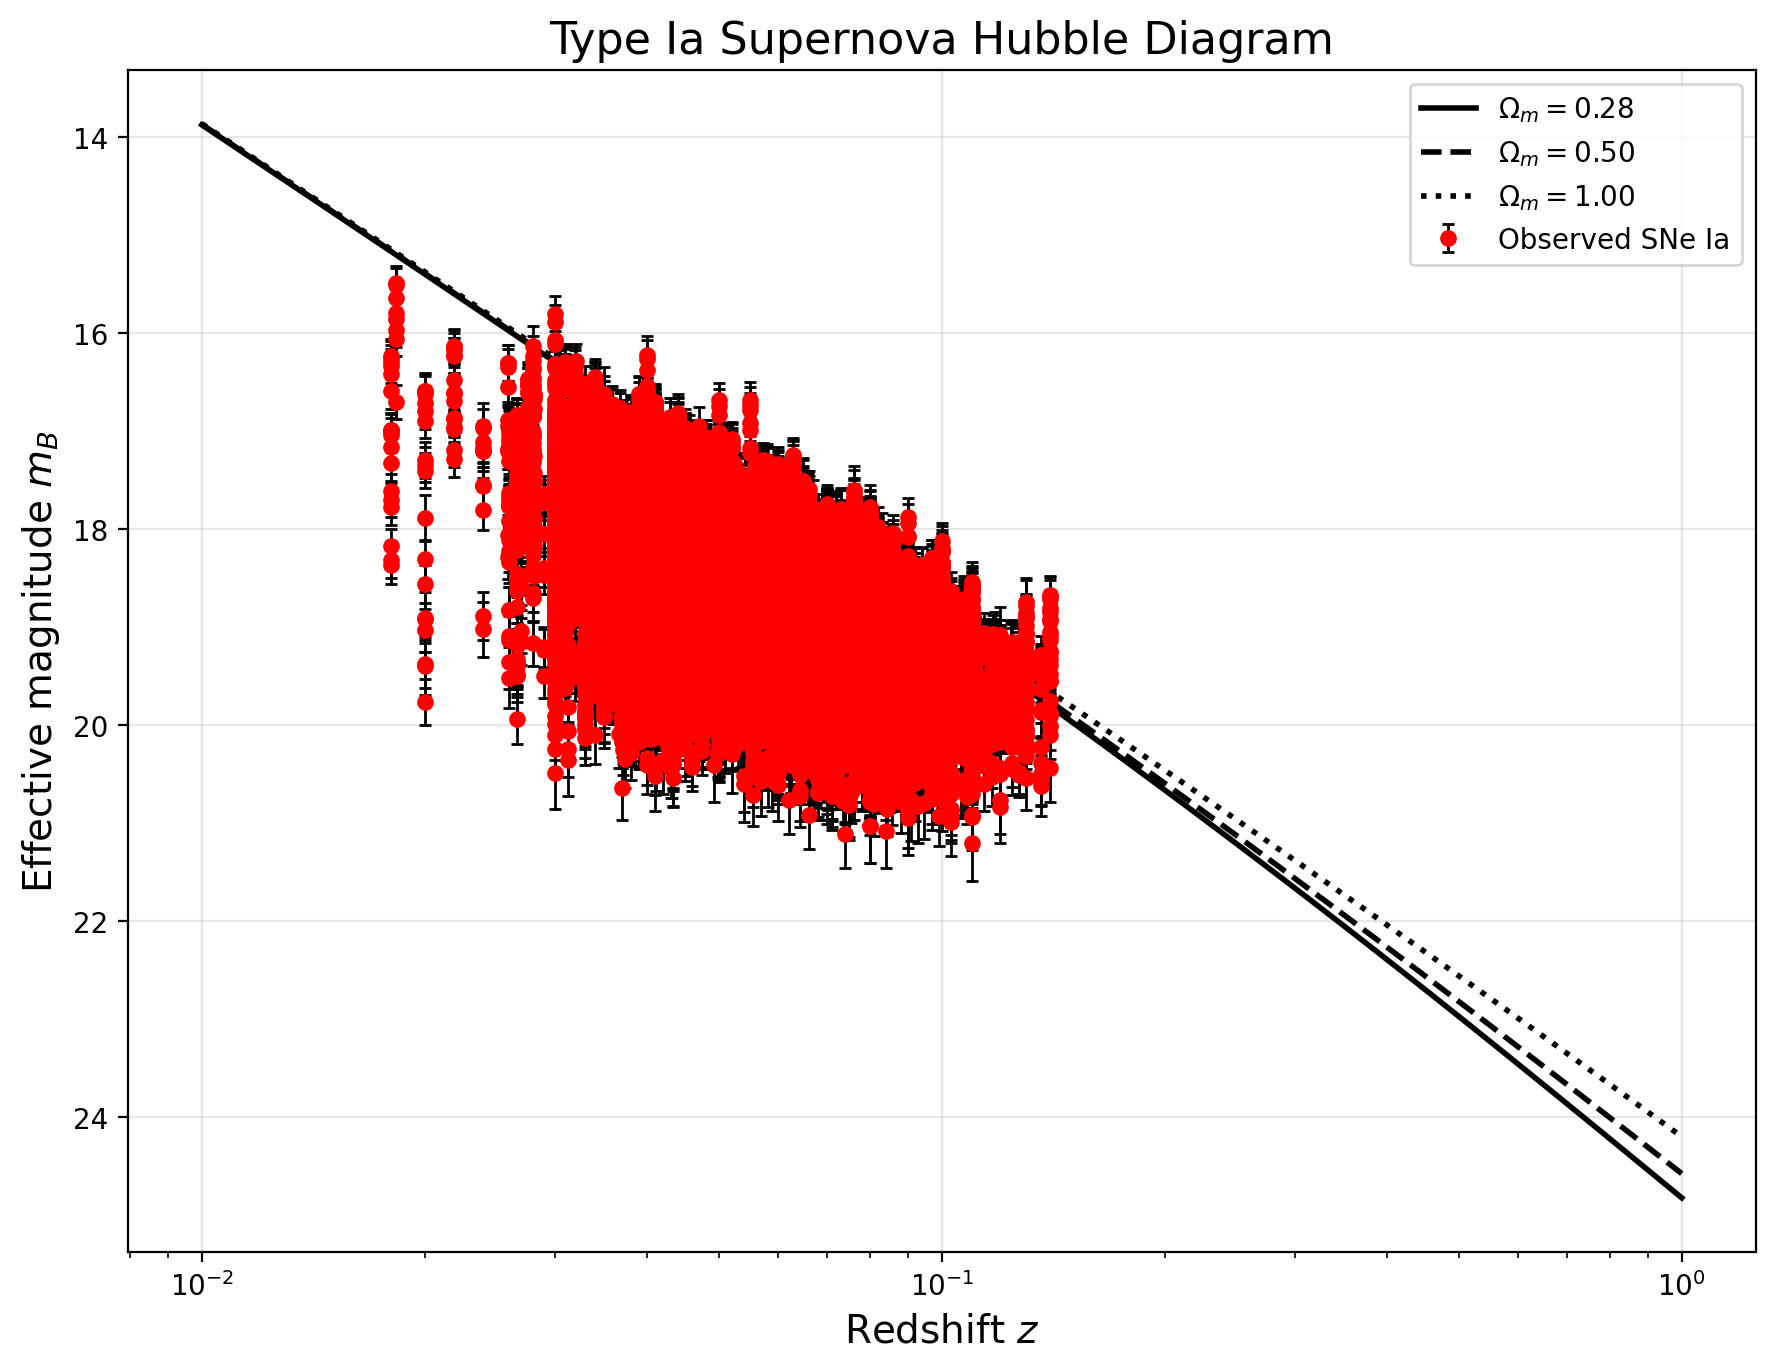

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# ------------------------------------------------------------
# Load saved Hubble-diagram data
# ------------------------------------------------------------
data_plot = pd.read_csv("mB_eff_data.csv")

z = data_plot['tns_redshift']
mB = data_plot['mB_eff']
mB_err = data_plot['e_mB_eff']

# ------------------------------------------------------------
# Plot SN data
# ------------------------------------------------------------
plt.figure(figsize=(9,7))

plt.errorbar(
    z,
    mB,
    yerr=mB_err,
    fmt='o',
    color='red',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    markersize=5,
    label='Observed SNe Ia'
)

# ------------------------------------------------------------
# Cosmology curves
# ------------------------------------------------------------
z_plot = np.logspace(np.log10(0.01), np.log10(1.0), 200)

def mag_model(z, Om, H0=70, M0=-19.3):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    return M0 + cosmo.distmod(z).value

plt.plot(z_plot, mag_model(z_plot,0.28),'k-',lw=2,label=r'$\Omega_m=0.28$')
plt.plot(z_plot, mag_model(z_plot,0.50),'k--',lw=2,label=r'$\Omega_m=0.50$')
plt.plot(z_plot, mag_model(z_plot,1.00),'k:',lw=2,label=r'$\Omega_m=1.00$')

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
plt.xscale('log')

plt.xlabel('Redshift $z$',fontsize=14)
plt.ylabel(r'Effective magnitude $m_B$',fontsize=14)

plt.gca().invert_yaxis()

plt.grid(True,alpha=0.3)
plt.legend()

plt.title("Type Ia Supernova Hubble Diagram",fontsize=16)

plt.tight_layout()
plt.show()

**after** **steve command**

In [18]:
import pandas as pd

data = pd.read_csv("mB_eff_data.csv")

# Select the row with minimum magnitude for each supernova
peak_data = data.loc[data.groupby("tns_name")["mB_eff"].idxmin()]

print("Number of supernovae:", len(peak_data))
print(peak_data.head())

# Save peak-only dataset
peak_data.to_csv("mB_eff_peak.csv", index=False)

Number of supernovae: 1442
      tns_name  tns_redshift     mB_eff  e_mB_eff
12819  2018cdt        0.0339  16.926003  0.171835
23725  2018cdu        0.0700  18.465373  0.178023
19573  2018cod        0.0300  17.177987  0.180333
5919   2018coe        0.0800  18.668037  0.177299
4146   2018cof        0.0916  18.715272  0.194505


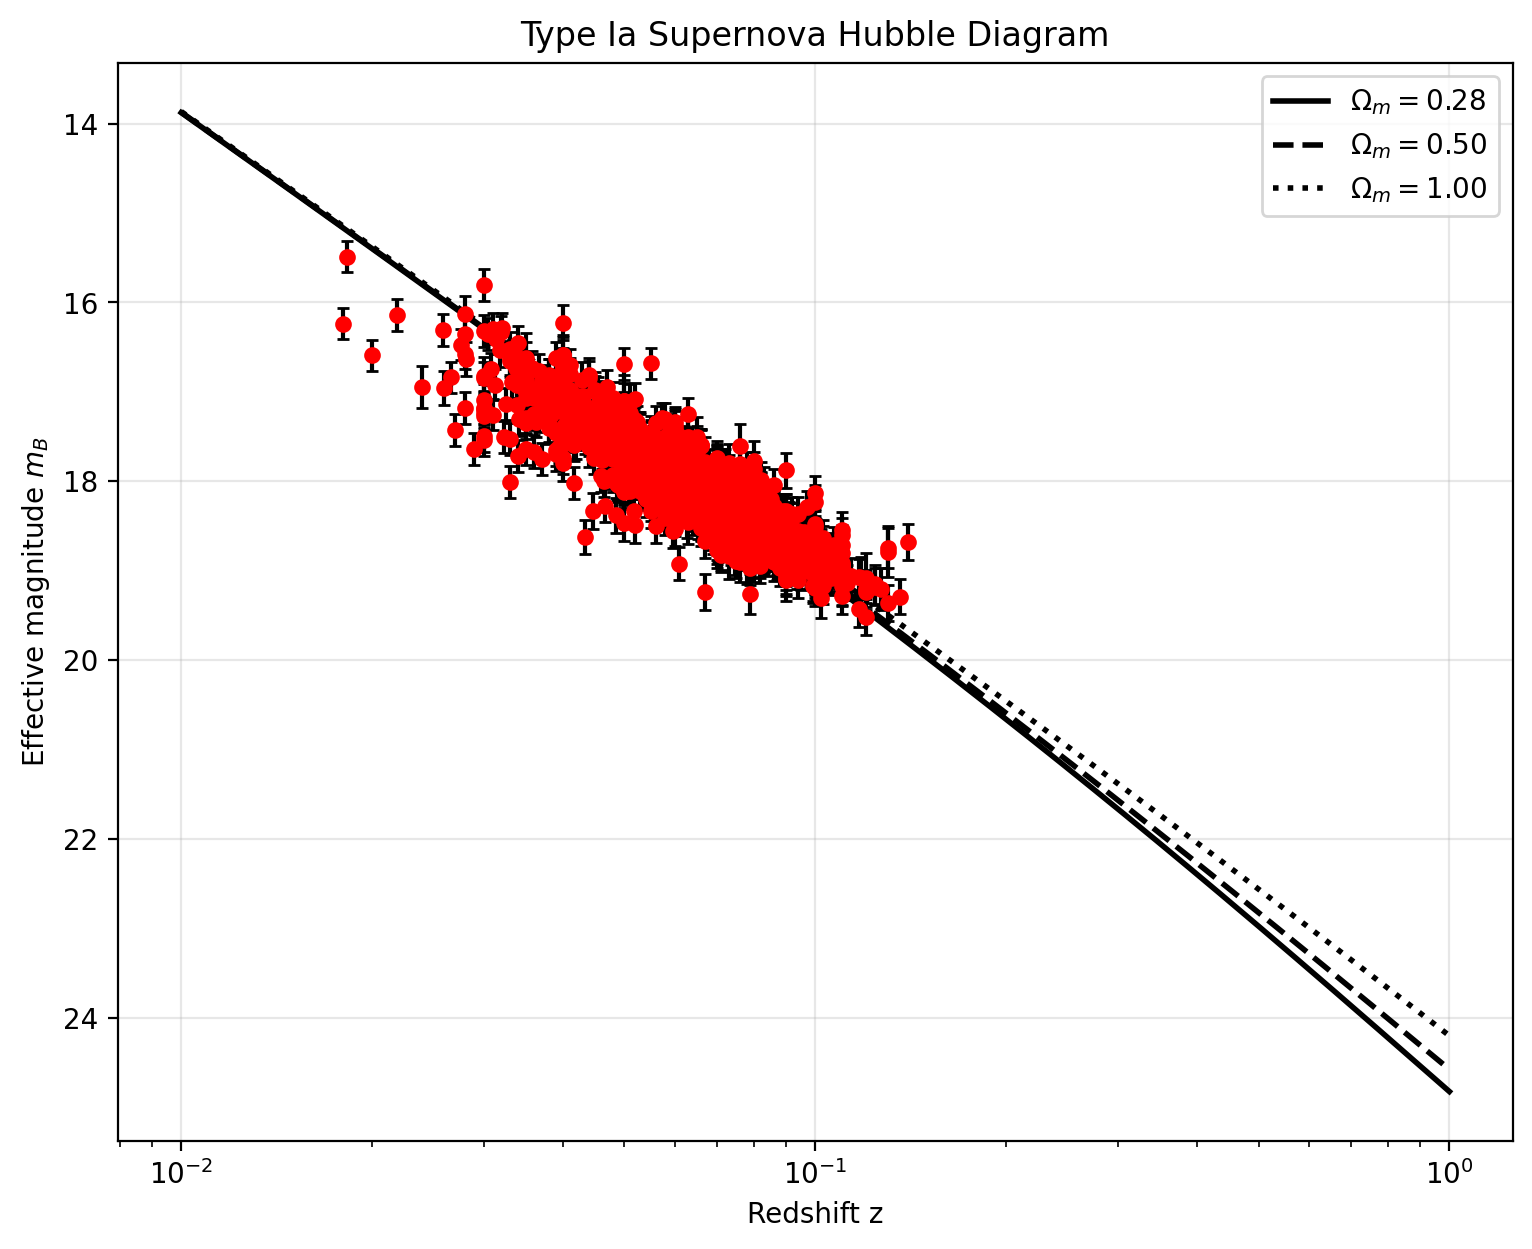

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM

data = pd.read_csv("mB_eff_peak.csv")

plt.figure(figsize=(9,7))

plt.errorbar(
    data["tns_redshift"],
    data["mB_eff"],
    yerr=data["e_mB_eff"],
    fmt='o',
    color='red',
    ecolor='black',
    capsize=2,
    markersize=5
)

# Cosmology curves
z_plot = np.logspace(np.log10(0.01), np.log10(1.0), 200)

def mag_model(z, Om, H0=70, M0=-19.3):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    return M0 + cosmo.distmod(z).value

plt.plot(z_plot, mag_model(z_plot,0.28),'k-',lw=2,label=r'$\Omega_m=0.28$')
plt.plot(z_plot, mag_model(z_plot,0.50),'k--',lw=2,label=r'$\Omega_m=0.50$')
plt.plot(z_plot, mag_model(z_plot,1.00),'k:',lw=2,label=r'$\Omega_m=1.00$')

plt.xscale("log")

plt.xlabel("Redshift z")
plt.ylabel("Effective magnitude $m_B$")

plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()

plt.title("Type Ia Supernova Hubble Diagram")

plt.show()

In [20]:
import pandas as pd

data = pd.read_csv("mB_eff_data.csv")

# select brightest point for each SN
peak_data = data.loc[data.groupby("tns_name")["mB_eff"].idxmin()]

print("Number of unique SNe:", len(peak_data))

# save cleaned dataset
peak_data.to_csv("mB_eff_peak.csv", index=False)

peak_data.head()

Number of unique SNe: 1442


,tns_name,tns_redshift,mB_eff,e_mB_eff
12819,2018cdt,0.0339,16.926003,0.171835
23725,2018cdu,0.0700,18.465373,0.178023
19573,2018cod,0.0300,17.177987,0.180333
5919,2018coe,0.0800,18.668037,0.177299
4146,2018cof,0.0916,18.715272,0.194505


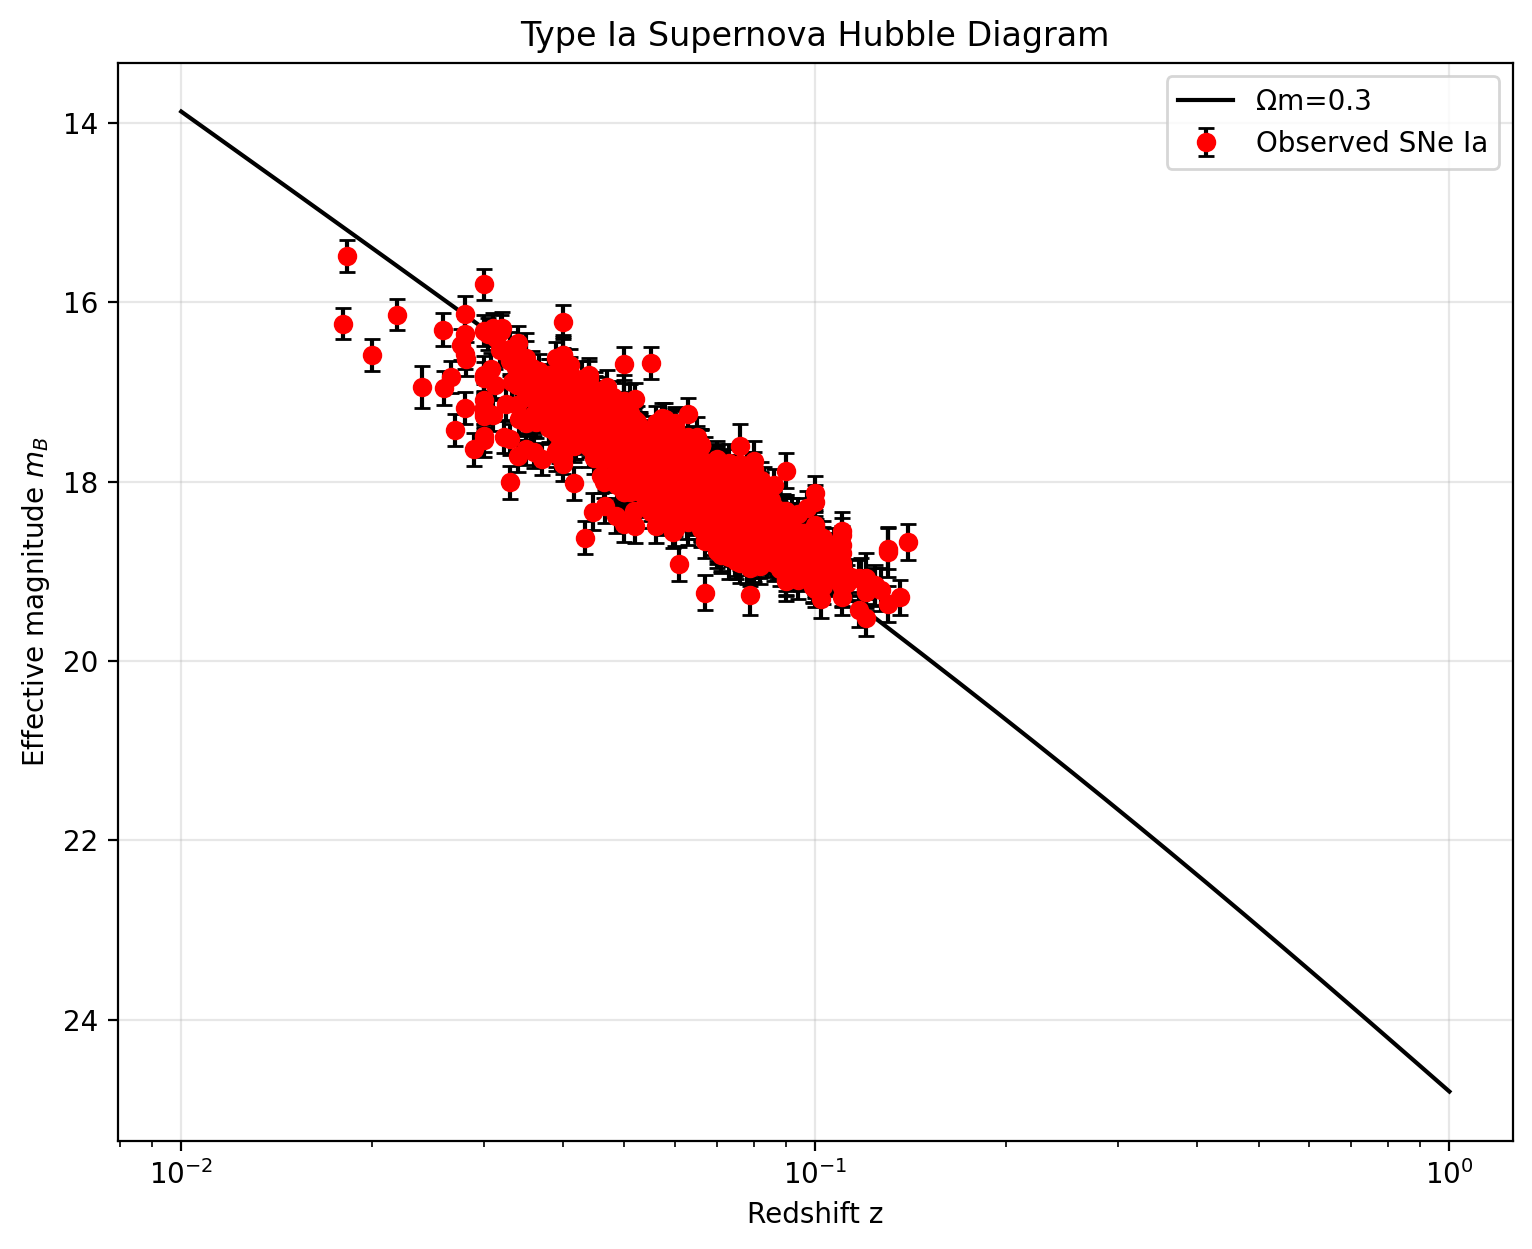

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

data = pd.read_csv("mB_eff_peak.csv")

plt.figure(figsize=(9,7))

plt.errorbar(
    data["tns_redshift"],
    data["mB_eff"],
    yerr=data["e_mB_eff"],
    fmt='o',
    color='red',
    ecolor='black',
    capsize=3,
    label="Observed SNe Ia"
)

# cosmology curves
z_plot = np.logspace(np.log10(0.01), np.log10(1.0), 200)

def mag_model(z, Om, H0, M0=-19.3):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    return M0 + cosmo.distmod(z).value

plt.plot(z_plot, mag_model(z_plot,0.3,70),'k-',label="Ωm=0.3")

plt.xscale("log")
plt.gca().invert_yaxis()

plt.xlabel("Redshift z")
plt.ylabel("Effective magnitude $m_B$")
plt.title("Type Ia Supernova Hubble Diagram")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [22]:
from scipy.optimize import minimize

z = data["tns_redshift"].values
m_obs = data["mB_eff"].values
err = data["e_mB_eff"].values

def chi2(params):
    H0 = params[0]
    m_model = mag_model(z,0.3,H0)
    return np.sum(((m_obs - m_model)/err)**2)

result = minimize(chi2,[70])

H0_best = result.x[0]

print("Best fit H0 =",H0_best,"km/s/Mpc")

Best fit H0 = 68.16298725346519 km/s/Mpc


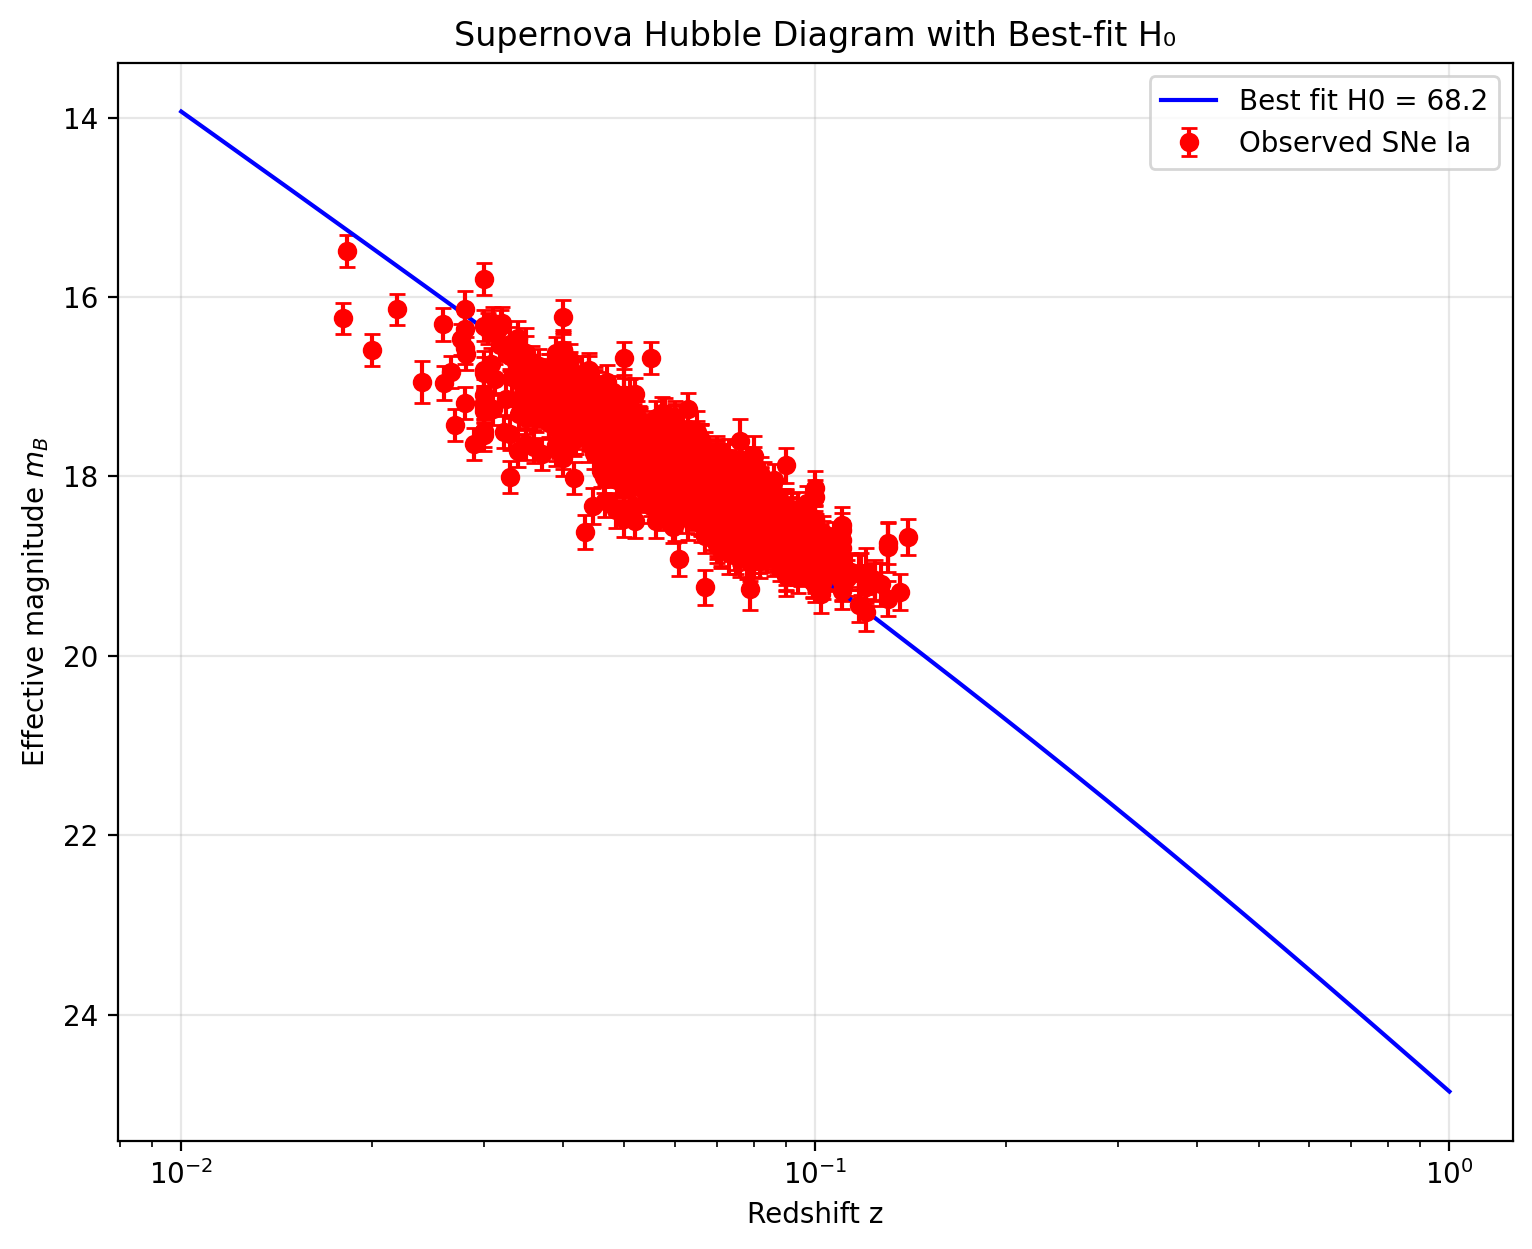

In [23]:
plt.figure(figsize=(9,7))

plt.errorbar(
    z,
    m_obs,
    yerr=err,
    fmt='o',
    color='red',
    capsize=3,
    label="Observed SNe Ia"
)

plt.plot(
    z_plot,
    mag_model(z_plot,0.3,H0_best),
    'b-',
    label=f"Best fit H0 = {H0_best:.1f}"
)

plt.xscale("log")
plt.gca().invert_yaxis()

plt.xlabel("Redshift z")
plt.ylabel("Effective magnitude $m_B$")
plt.title("Supernova Hubble Diagram with Best-fit H₀")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

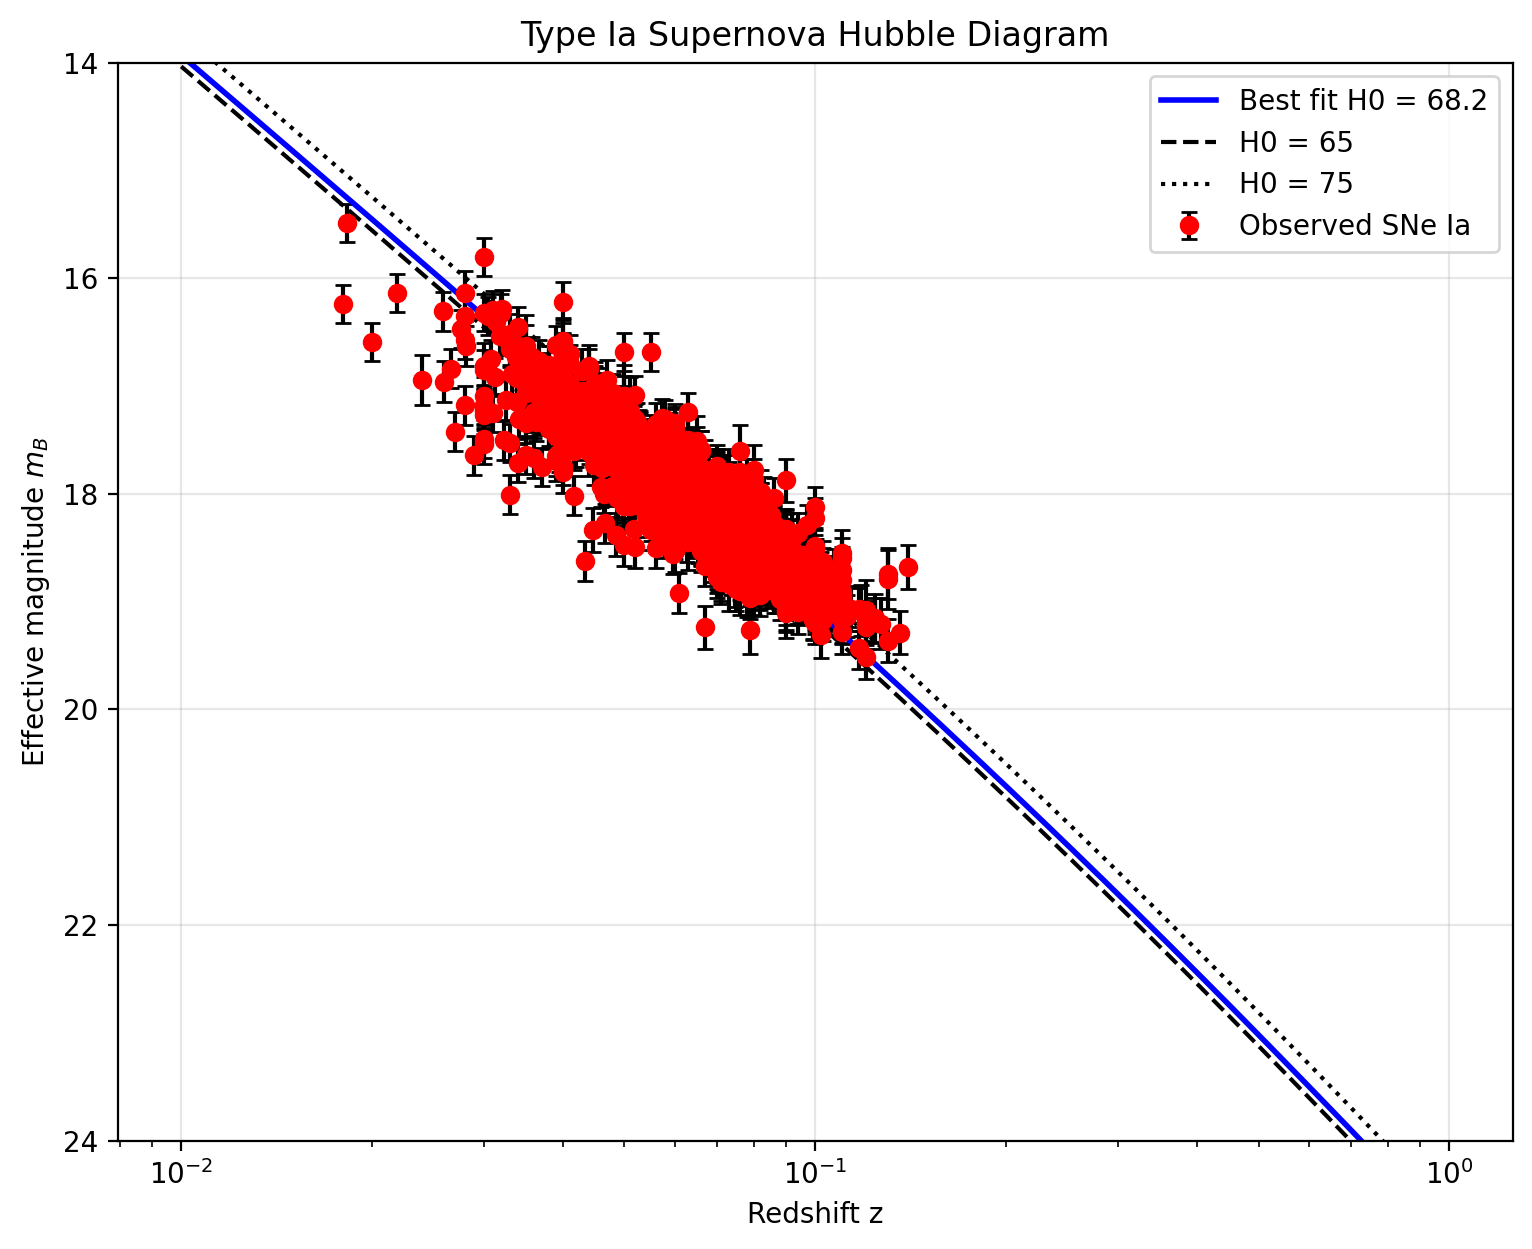

In [24]:
plt.figure(figsize=(9,7))

plt.errorbar(
    z,
    m_obs,
    yerr=err,
    fmt='o',
    color='red',
    ecolor='black',
    capsize=3,
    label="Observed SNe Ia"
)

# redshift grid
z_plot = np.logspace(np.log10(0.01), np.log10(1.0), 200)

# best-fit model
plt.plot(
    z_plot,
    mag_model(z_plot,0.3,H0_best),
    color='blue',
    linewidth=2,
    label=f"Best fit H0 = {H0_best:.1f}"
)

# comparison models
plt.plot(z_plot, mag_model(z_plot,0.3,65),'k--',label="H0 = 65")
plt.plot(z_plot, mag_model(z_plot,0.3,75),'k:',label="H0 = 75")

plt.xscale("log")

# correct magnitude orientation
plt.ylim(24,14)

plt.xlabel("Redshift z")
plt.ylabel("Effective magnitude $m_B$")

plt.title("Type Ia Supernova Hubble Diagram")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

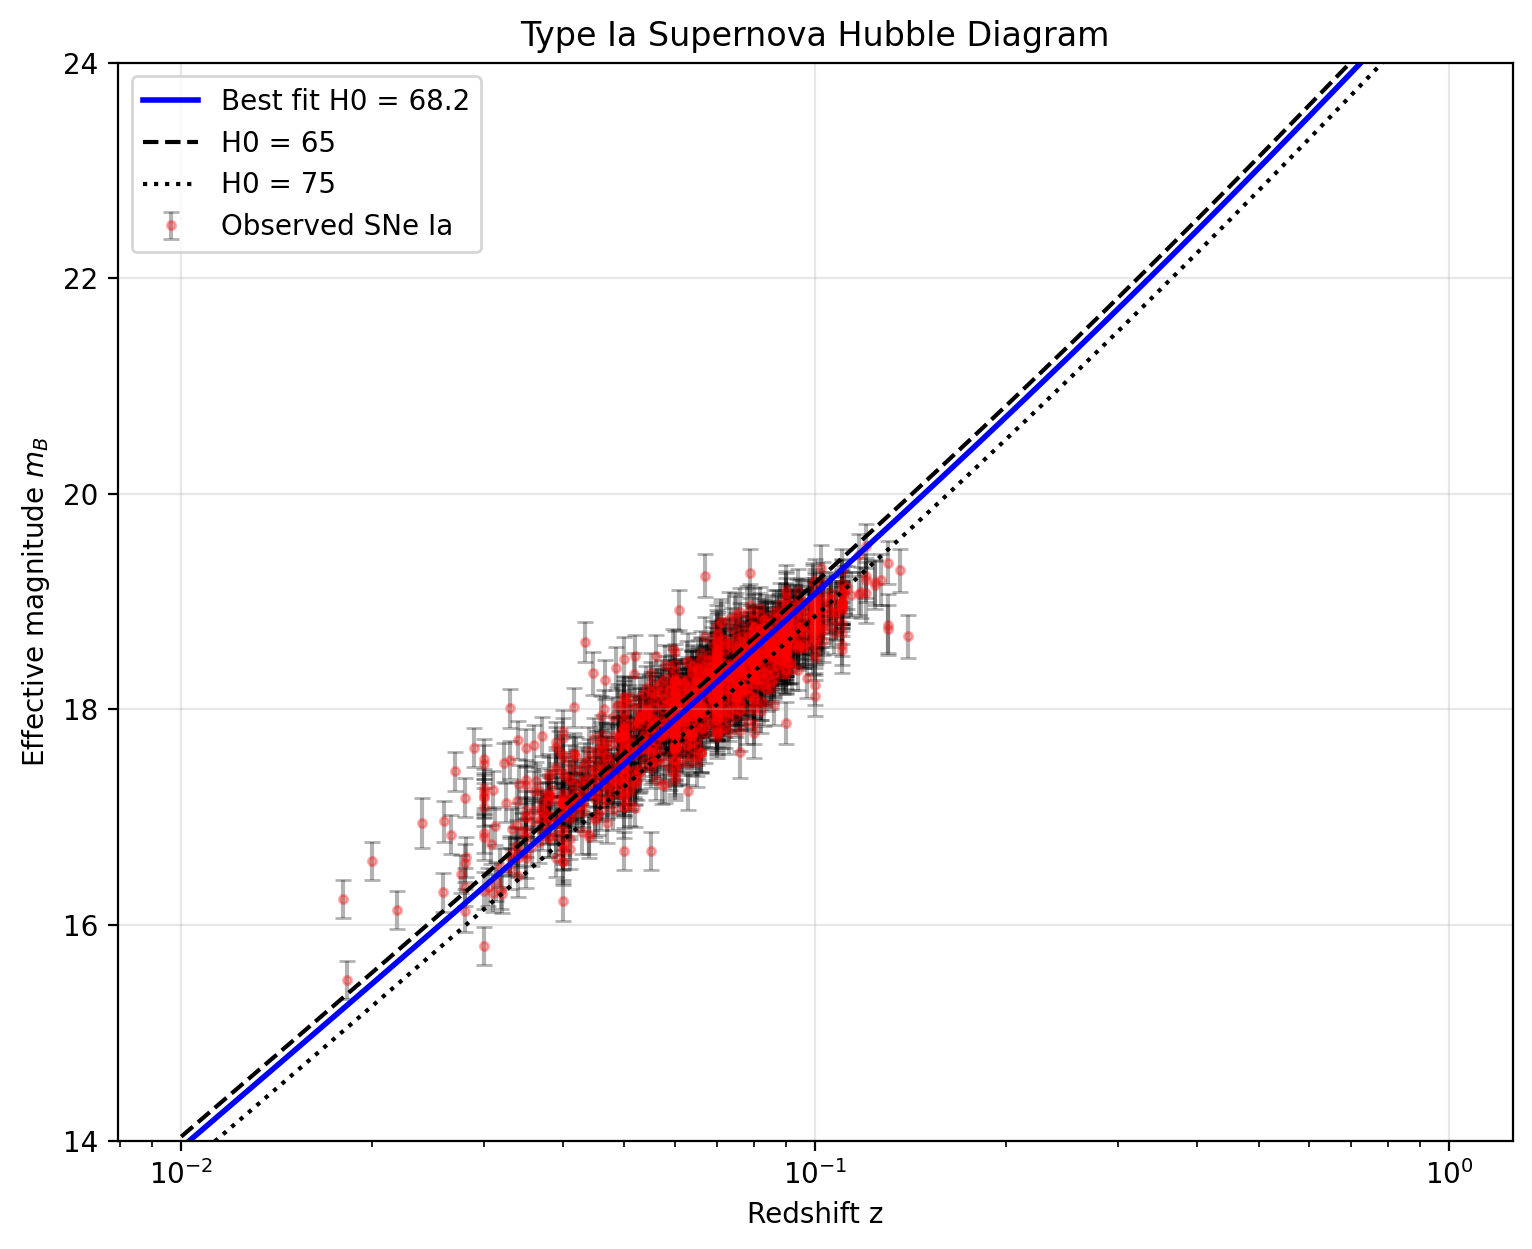

In [38]:
plt.figure(figsize=(9,7))

plt.errorbar(
    z,
    m_obs,
    yerr=err,
    fmt='.',alpha=0.3,zorder=1,
    color='red',
    ecolor='black',
    capsize=3,
    label="Observed SNe Ia"
)

z_plot = np.logspace(np.log10(0.01), np.log10(1.0), 200)

plt.plot(
    z_plot,
    mag_model(z_plot,0.3,H0_best),zorder=2,
    color='blue',
    linewidth=2,
    label=f"Best fit H0 = {H0_best:.1f}"
)

plt.plot(z_plot, mag_model(z_plot,0.3,65),'k--',label="H0 = 65")
plt.plot(z_plot, mag_model(z_plot,0.3,75),'k:',label="H0 = 75")

plt.xscale("log")

# Normal axis (for understanding)
plt.ylim(14,24)

plt.xlabel("Redshift z")
plt.ylabel("Effective magnitude $m_B$")

plt.title("Type Ia Supernova Hubble Diagram")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import z_at_value
import astropy.units as u
from dustmaps.sfonds import SFondQuery
from dustmaps.sfonds import SFondQuery as SFD
import warnings

# ------------------------------------------------------------
# 1. Input your data – expected columns in a CSV file:
#    z, m_obs, filter, s, K, A_gal (or you can compute A_gal from coordinates)
#    If you provide RA, Dec, we can compute A_gal on the fly.
# ------------------------------------------------------------
# Example data structure:
# z, m_obs, filter, s, K, A_gal, error_m_obs, error_s
# If you have RA, Dec, we can compute Galactic extinction, so you may omit A_gal.
# For now we assume a file 'my_sn_data.csv' with all necessary columns.

data = pd.read_csv('df_snia_with_tns_match_plus_dm15.csv')

# If you need to compute A_gal from RA, Dec (in degrees) using the Schlegel map:
# sfond = SFondQuery()
# def galactic_extinction(ra, dec, filter_band):
#     ebv = sfond(ra, dec)  # E(B-V) from Schlegel et al.
#     # Convert to extinction in the observed band using an appropriate R_X
#     # For example, R_R ~ 2.6 at low z, but depends on redshift. 
#     # For simplicity we assume you have precomputed A_gal.
#     return A_gal

# ------------------------------------------------------------
# 2. Choose the width–luminosity slope α
# ------------------------------------------------------------
alpha = 0.6  # from the paper, or you can fit it (see below)

# Compute effective B-band magnitude
data['magpsf'] = data['m_obs'] + alpha * (data['s'] - 1) - data['K'] - data['A_gal']

# Propagate uncertainties (simple addition in quadrature, ignoring covariances)
# You need uncertainties on m_obs, s, K, A_gal. Assume they are given.
data['error_magpsf'] = np.sqrt(data['error_m_obs']**2 + 
                                (alpha * data['error_s'])**2 +
                                data.get('error_K', 0.0)**2 +
                                data.get('error_A_gal', 0.0)**2 +
                                0.17**2)  # intrinsic SN Ia dispersion (add if desired)

# ------------------------------------------------------------
# 3. Plot effective magnitude vs redshift
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.errorbar(data['z'], data['mB_eff'], yerr=data['error_mB_eff'], 
             fmt='o', capsize=2, label='My SNe Ia')

# Overplot theoretical curves for different cosmologies using astropy
z_plot = np.linspace(0, max(data['z']), 100)
# Flat cosmologies with different Ωm
cosmo1 = FlatLambdaCDM(H0=70, Om0=0.28)   # best-fit from paper
cosmo2 = FlatLambdaCDM(H0=70, Om0=0.5)
cosmo3 = FlatLambdaCDM(H0=70, Om0=1.0)

# Distance modulus (m-M) = 5 log10(d_L/10pc). We need to adjust the zero-point.
# The zero-point is M_B + 5 log10(H0/70) + constant? Actually from the paper:
# mB_eff = M_B + 5 log10(d_L) + constant. To plot, we can use the same absolute magnitude
# as the low-z sample. We'll just shift the curves vertically to match the data.
# One approach: use a reference supernova at low z to determine the offset.
# For simplicity, we set a zero-point that roughly aligns with the data.
# In a real analysis you would fit M_B and α together with ΩM,ΩΛ.

def mag_model(z, Om, H0=70, M0=-19.3):  # M0 is an approximate absolute magnitude
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    dist_mod = cosmo.distmod(z).value
    return M0 + dist_mod

# Plot the models
plt.plot(z_plot, mag_model(z_plot, 0.28), 'r-', label=r'$\Omega_m=0.28$, flat')
plt.plot(z_plot, mag_model(z_plot, 0.5), 'g--', label=r'$\Omega_m=0.5$, flat')
plt.plot(z_plot, mag_model(z_plot, 1.0), 'b:', label=r'$\Omega_m=1.0$, flat')

plt.xlabel('Redshift z')
plt.ylabel(r'$m_B^{\mathrm{eff}}$')
plt.legend()
plt.gca().invert_yaxis()  # fainter downwards
plt.show()

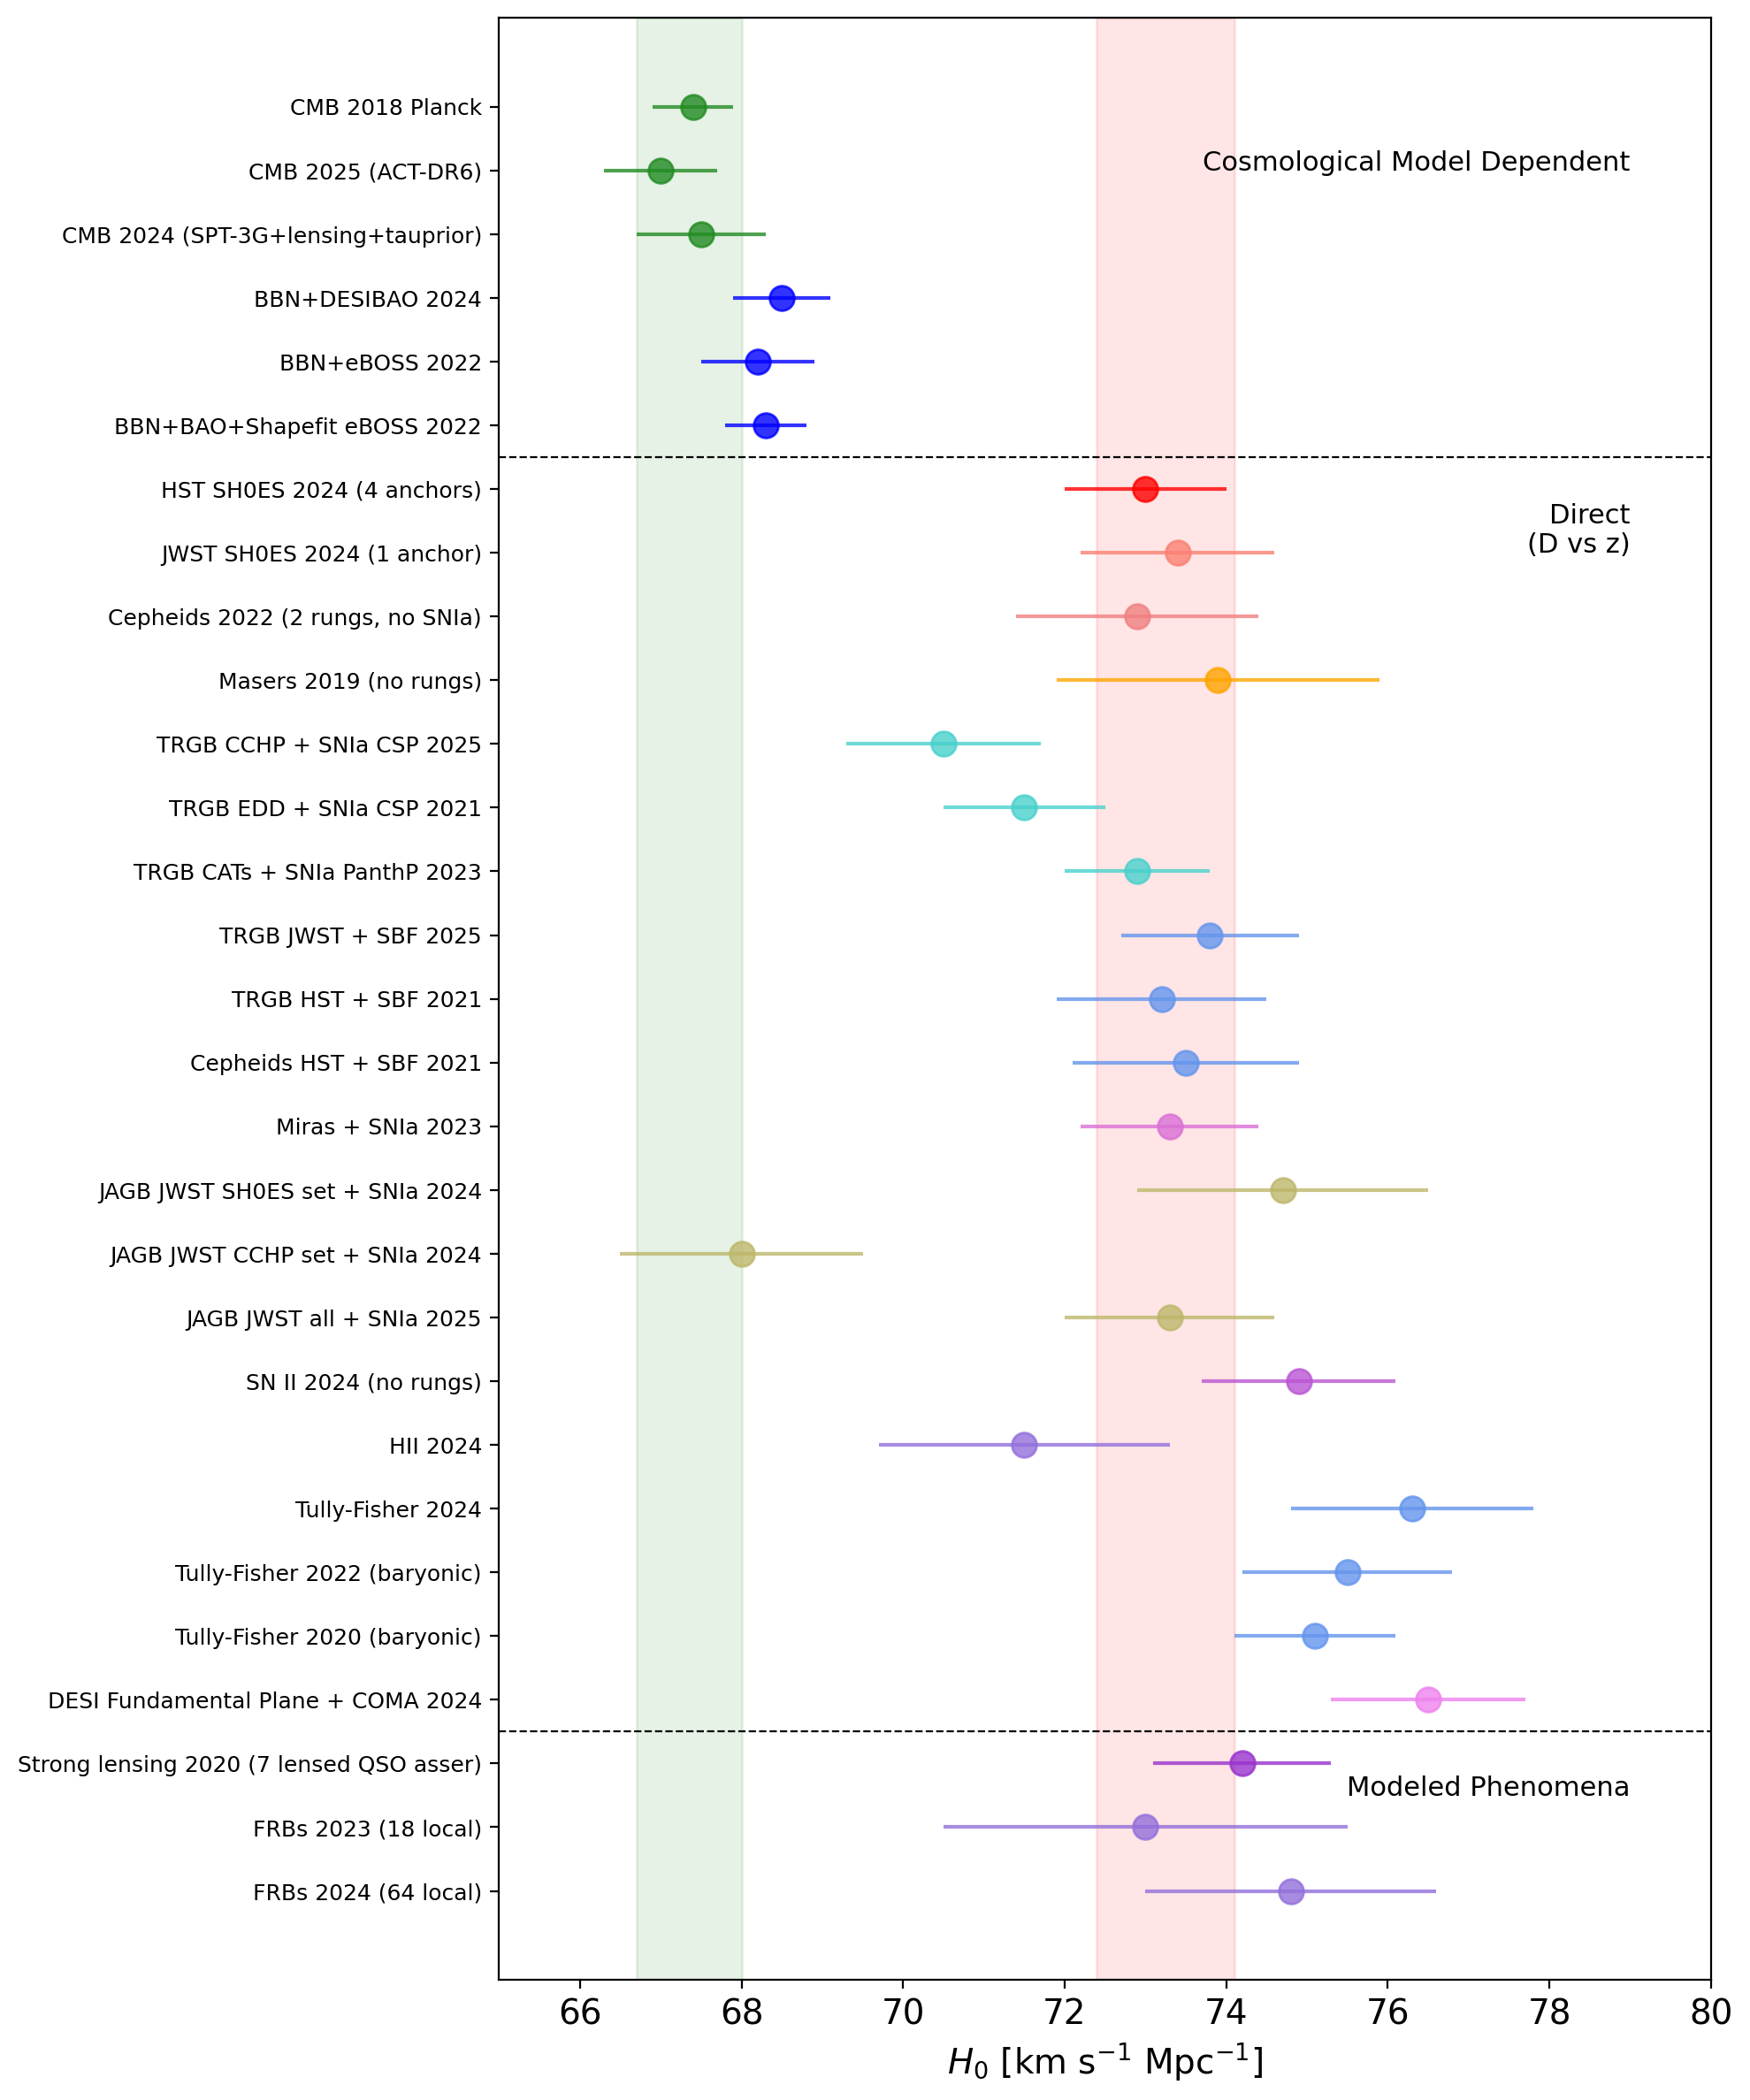

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de los datos (Valores aproximados basados en la imagen)
# Formato: (Etiqueta, Valor, Error, Color)
data_cosmo = [
    ("CMB 2018 Planck", 67.4, 0.5, 'forestgreen'),
    ("CMB 2025 (ACT-DR6)", 67.0, 0.7, 'forestgreen'),
    ("CMB 2024 (SPT-3G+lensing+tauprior)", 67.5, 0.8, 'forestgreen'),
    ("BBN+DESIBAO 2024", 68.5, 0.6, 'blue'),
    ("BBN+eBOSS 2022", 68.2, 0.7, 'blue'),
    ("BBN+BAO+Shapefit eBOSS 2022", 68.3, 0.5, 'blue'),
]

data_direct = [
    ("HST SH0ES 2024 (4 anchors)", 73.0, 1.0, 'red'),
    ("JWST SH0ES 2024 (1 anchor)", 73.4, 1.2, 'salmon'),
    ("Cepheids 2022 (2 rungs, no SNIa)", 72.9, 1.5, 'lightcoral'),
    ("Masers 2019 (no rungs)", 73.9, 2.0, 'orange'),
    ("TRGB CCHP + SNIa CSP 2025", 70.5, 1.2, 'mediumturquoise'),
    ("TRGB EDD + SNIa CSP 2021", 71.5, 1.0, 'mediumturquoise'),
    ("TRGB CATs + SNIa PanthP 2023", 72.9, 0.9, 'mediumturquoise'),
    ("TRGB JWST + SBF 2025", 73.8, 1.1, 'cornflowerblue'),
    ("TRGB HST + SBF 2021", 73.2, 1.3, 'cornflowerblue'),
    ("Cepheids HST + SBF 2021", 73.5, 1.4, 'cornflowerblue'),
    ("Miras + SNIa 2023", 73.3, 1.1, 'orchid'),
    ("JAGB JWST SH0ES set + SNIa 2024", 74.7, 1.8, 'darkkhaki'),
    ("JAGB JWST CCHP set + SNIa 2024", 68.0, 1.5, 'darkkhaki'),
    ("JAGB JWST all + SNIa 2025", 73.3, 1.3, 'darkkhaki'),
    ("SN II 2024 (no rungs)", 74.9, 1.2, 'mediumorchid'),
    ("HII 2024", 71.5, 1.8, 'mediumpurple'),
    ("Tully-Fisher 2024", 76.3, 1.5, 'cornflowerblue'),
    ("Tully-Fisher 2022 (baryonic)", 75.5, 1.3, 'cornflowerblue'),
    ("Tully-Fisher 2020 (baryonic)", 75.1, 1.0, 'cornflowerblue'),
    ("DESI Fundamental Plane + COMA 2024", 76.5, 1.2, 'violet'),
]

data_modeled = [
    ("Strong lensing 2020 (7 lensed QSO asser)", 74.2, 1.1, 'darkorchid'),
    ("FRBs 2023 (18 local)", 73.0, 2.5, 'mediumpurple'),
    ("FRBs 2024 (64 local)", 74.8, 1.8, 'mediumpurple'),
]

# Unificar datos y calcular posiciones Y
all_data = data_cosmo + data_direct + data_modeled
labels = [d[0] for d in all_data]
values = [d[1] for d in all_data]
errors = [d[2] for d in all_data]
colors = [d[3] for d in all_data]
y_pos = np.arange(len(all_data))

# Crear la figura
fig, ax = plt.subplots(figsize=(10, 12))

# Dibujar las bandas de fondo (Sombreado verde y rosa)
ax.axvspan(66.7, 68.0, color='green', alpha=0.1, zorder=0)
ax.axvspan(72.4, 74.1, color='red', alpha=0.1, zorder=0)

# Dibujar puntos con barras de error
for i in range(len(all_data)):
    ax.errorbar(values[i], i, xerr=errors[i], fmt='o', color=colors[i], 
                markersize=10, capsize=0, elinewidth=1.5, alpha=0.8)

# Configurar ejes y etiquetas
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()  # Para que el primer dato esté arriba
ax.set_xlabel(r'$H_0$ [km s$^{-1}$ Mpc$^{-1}$]', fontsize=14)
ax.set_xlim(65, 80)

# Líneas divisorias horizontales
ax.axhline(y=len(data_cosmo) - 0.5, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=len(data_cosmo) + len(data_direct) - 0.5, color='black', linestyle='--', linewidth=0.8)

# Anotaciones de secciones
ax.text(79, 1, "Cosmological Model Dependent", ha='right', fontsize=11)
ax.text(79, 7, "Direct\n(D vs z)", ha='right', fontsize=11)
ax.text(79, 26.5, "Modeled Phenomena", ha='right', fontsize=11)

# Estética final
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', labelsize=14)
plt.tight_layout()

plt.show()
